In [4]:
import pandas as pd
import numpy as np
import torch
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
lstm_model = torch.load('../models/LSTM_10epochs_final.pth', map_location=torch.device('cpu'))
trans_model = torch.load('../models/Transformer_13epochs_final.pth', map_location=torch.device('cpu'))
lstm_state_dict = lstm_model['model_state_dict']
trans_state_dict = trans_model['model_state_dict']

lstm_total_params = sum(p.numel() for p in lstm_state_dict.values())
print(f"LSTM total parameters: {lstm_total_params:,}")
trans_total_params = sum(v.numel() for k, v in trans_state_dict.items() if 'pe' not in k)
print(f"Transformer total parameters: {trans_total_params:,}")

LSTM total parameters: 819,228
Transformer total parameters: 899,356


C:\Users\juliub\AppData\Local\Temp\ipykernel_37360\2541742684.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_model = torch.load('../models/LSTM_10epochs_final.pth'

In [6]:
lstm_hist = pd.DataFrame.from_dict(lstm_model['history'], orient='columns')
trans_hist = pd.DataFrame.from_dict(trans_model['history'], orient='columns')

lstm_hist['epoch'] = lstm_hist['epoch'] + 1
trans_hist['epoch'] = trans_hist['epoch'] + 1

lstm_hist.head(15)

,train_loss,val_loss,epoch,epoch_time
0,0.000018,0.000009,1,143.312601
1,0.000010,0.000010,2,141.593970
2,0.000010,0.000009,3,145.149529
3,0.000010,0.000009,4,143.226358
4,0.000010,0.000010,5,143.478397
5,0.000010,0.000009,6,142.360926
6,0.000010,0.000010,7,144.418147
7,0.000010,0.000010,8,145.166261
8,0.000010,0.000010,9,144.589173
9,0.000010,0.000010,10,145.971475


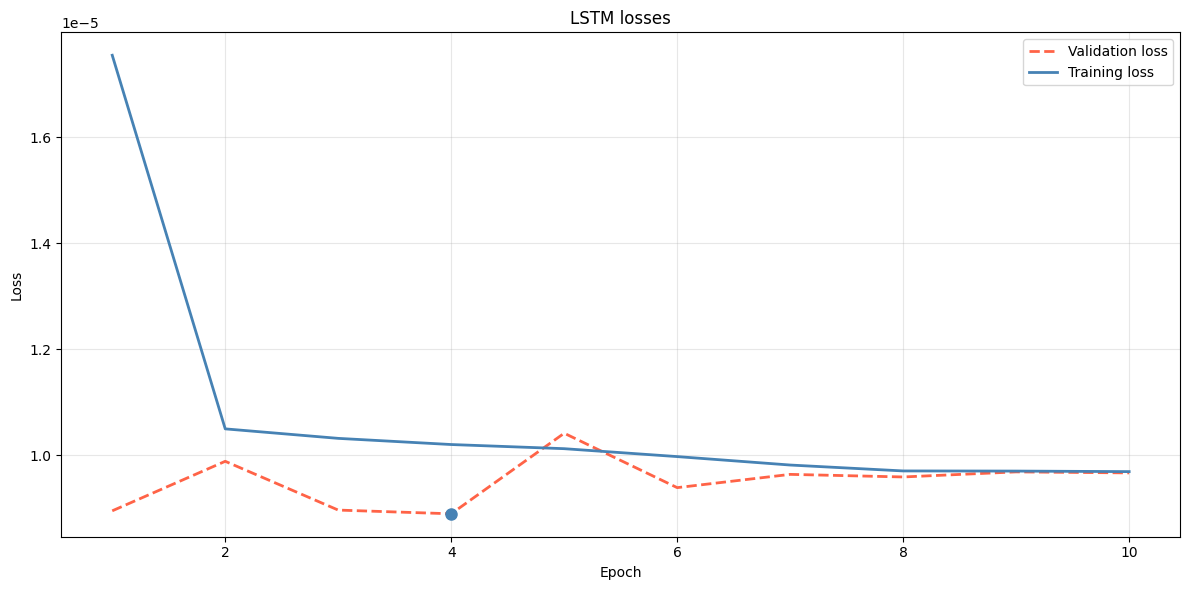

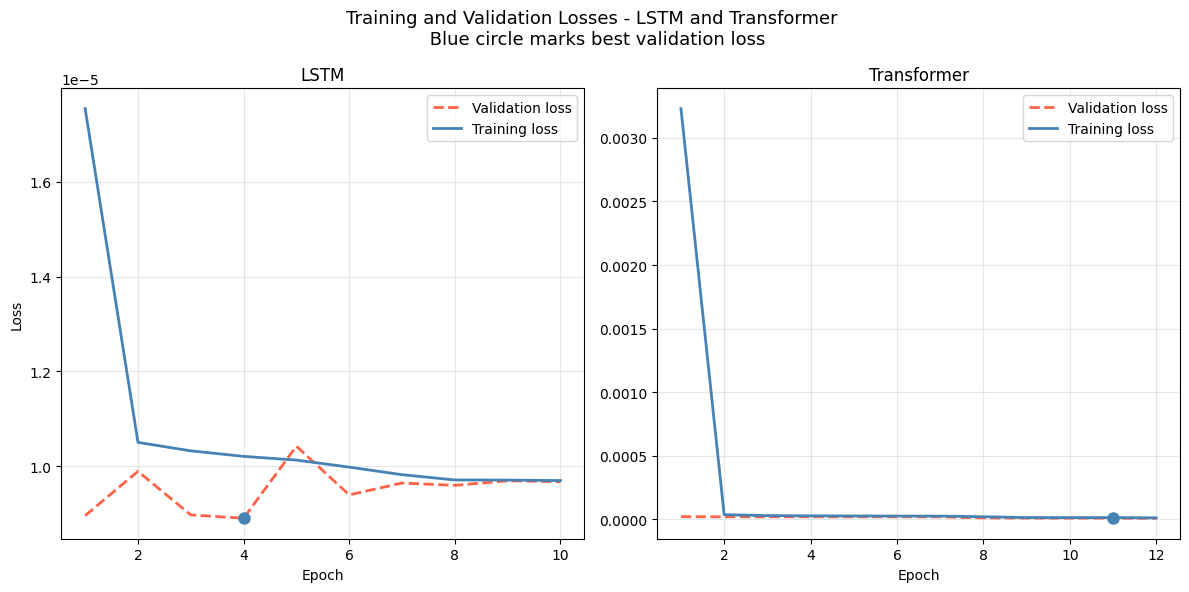

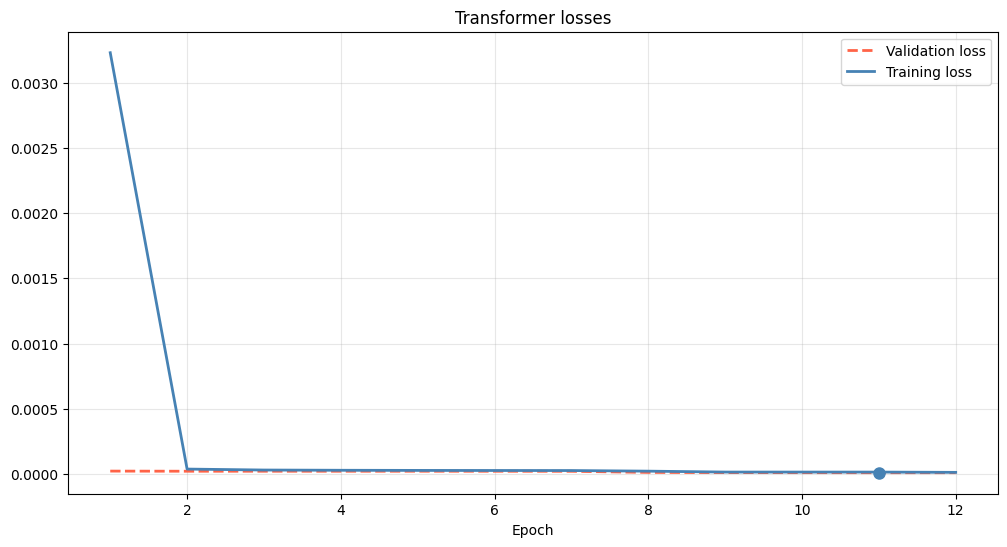

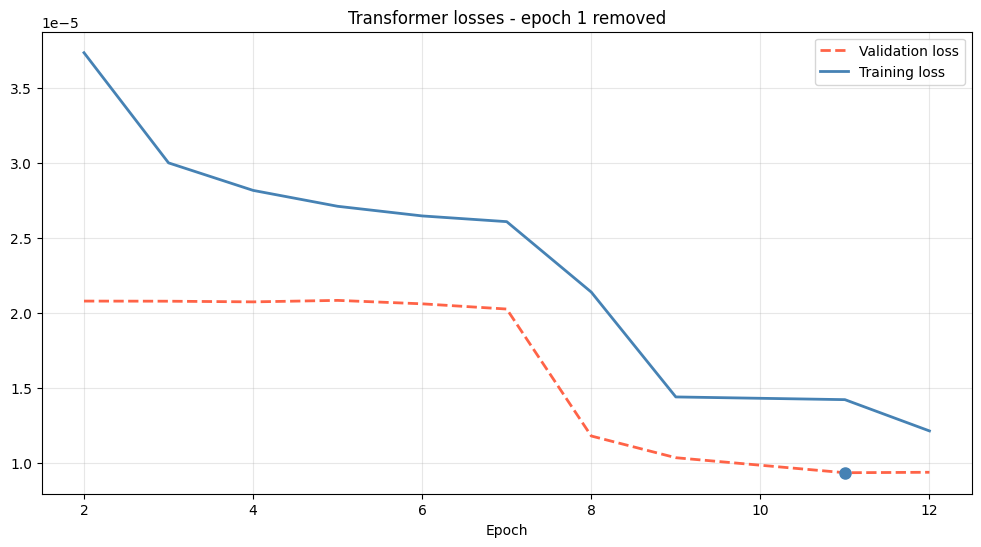

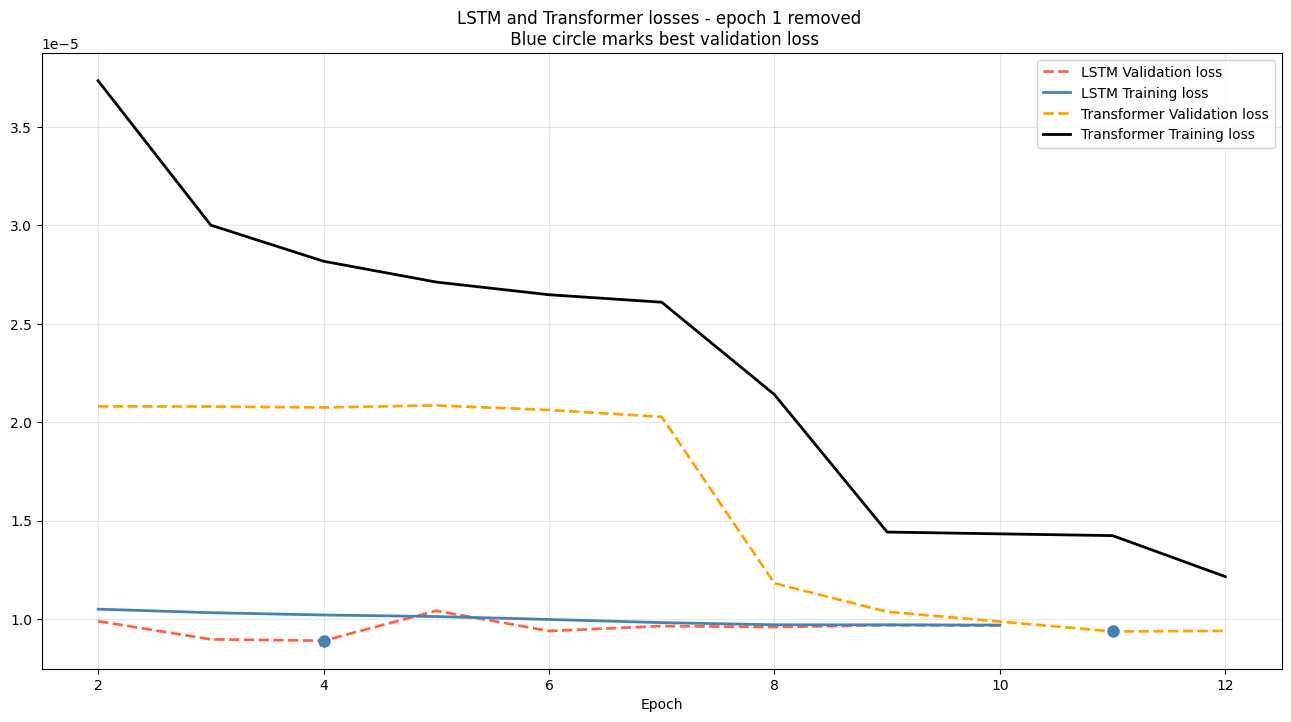

In [7]:
lstm_hist_epoch_rem = lstm_hist[lstm_hist['epoch'] >= 2]
trans_hist_epoch_rem = trans_hist[trans_hist['epoch'] >= 2]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(lstm_hist['epoch'], lstm_hist['val_loss'], label='Validation loss', linewidth=2, color='tomato', linestyle='--')
ax.plot(lstm_hist['epoch'], lstm_hist['train_loss'], label='Training loss', linewidth=2, color='steelblue')
ax.set_title('LSTM losses')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(alpha=0.3)
best_epoch = lstm_hist['val_loss'].idxmin()
best_loss = lstm_hist['val_loss'].min()
ax.plot(lstm_hist['epoch'][best_epoch], best_loss, marker='o', color='steelblue', markersize=8)
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.tight_layout()
plt.show()





fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
fig.suptitle('Training and Validation Losses - LSTM and Transformer \n Blue circle marks best validation loss', fontsize=13)

ax1.plot(lstm_hist['epoch'], lstm_hist['val_loss'], label='Validation loss', linewidth=2, color='tomato', linestyle='--')
ax1.plot(lstm_hist['epoch'], lstm_hist['train_loss'], label='Training loss', linewidth=2, color='steelblue')
ax1.set_title('LSTM')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)
best_epoch = lstm_hist['val_loss'].idxmin()
best_loss = lstm_hist['val_loss'].min()
ax1.plot(lstm_hist['epoch'][best_epoch], best_loss, marker='o', color='steelblue', markersize=8)
ax1.xaxis.set_major_locator(plt.MultipleLocator(2))

ax2.plot(trans_hist['epoch'], trans_hist['val_loss'], label='Validation loss', linewidth=2, color='tomato', linestyle='--')
ax2.plot(trans_hist['epoch'], trans_hist['train_loss'], label='Training loss', linewidth=2, color='steelblue')
ax2.set_title('Transformer')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(alpha=0.3)
best_epoch = trans_hist['val_loss'].idxmin()
best_loss = trans_hist['val_loss'].min()
ax2.plot(trans_hist['epoch'][best_epoch], best_loss, marker='o', color='steelblue', markersize=8)
ax2.xaxis.set_major_locator(plt.MultipleLocator(2))

plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(trans_hist['epoch'], trans_hist['val_loss'], label='Validation loss', linewidth=2, color='tomato', linestyle='--')
ax.plot(trans_hist['epoch'], trans_hist['train_loss'], label='Training loss', linewidth=2, color='steelblue')
best_epoch = trans_hist['val_loss'].idxmin()
best_loss = trans_hist['val_loss'].min()
ax.plot(trans_hist['epoch'][best_epoch], best_loss, marker='o', color='steelblue', markersize=8)
ax.set_title('Transformer losses')
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.show()


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(trans_hist_epoch_rem['epoch'], trans_hist_epoch_rem['val_loss'], label='Validation loss', linewidth=2, color='tomato', linestyle='--')
ax.plot(trans_hist_epoch_rem['epoch'], trans_hist_epoch_rem['train_loss'], label='Training loss', linewidth=2, color='steelblue')
best_epoch = trans_hist_epoch_rem['val_loss'].idxmin()
best_loss = trans_hist_epoch_rem['val_loss'].min()
ax.plot(trans_hist_epoch_rem['epoch'][best_epoch], best_loss, marker='o', color='steelblue', markersize=8)
ax.set_title('Transformer losses - epoch 1 removed')
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.show()





fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(lstm_hist_epoch_rem['epoch'], lstm_hist_epoch_rem['val_loss'], label='LSTM Validation loss', linewidth=2, color='tomato', linestyle='--')
ax.plot(lstm_hist_epoch_rem['epoch'], lstm_hist_epoch_rem['train_loss'], label='LSTM Training loss', linewidth=2, color='steelblue')
best_epoch = lstm_hist_epoch_rem['val_loss'].idxmin()
best_loss = lstm_hist_epoch_rem['val_loss'].min()
ax.plot(lstm_hist_epoch_rem['epoch'][best_epoch], best_loss, marker='o', color='steelblue', markersize=8)

ax.plot(trans_hist_epoch_rem['epoch'], trans_hist_epoch_rem['val_loss'], label='Transformer Validation loss', linewidth=2, color='orange', linestyle='--')
ax.plot(trans_hist_epoch_rem['epoch'], trans_hist_epoch_rem['train_loss'], label='Transformer Training loss', linewidth=2, color='black')
best_epoch = trans_hist_epoch_rem['val_loss'].idxmin()
best_loss = trans_hist_epoch_rem['val_loss'].min()
ax.plot(trans_hist_epoch_rem['epoch'][best_epoch], best_loss, marker='o', color='steelblue', markersize=8)
ax.xaxis.set_major_locator(plt.MultipleLocator(2))

ax.set_title('LSTM and Transformer losses - epoch 1 removed \n Blue circle marks best validation loss')
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

In [8]:
print(trans_hist['train_loss'].max())
print(lstm_hist['train_loss'].min(), lstm_hist['val_loss'].min())
print(trans_hist['train_loss'].min(), trans_hist['val_loss'].min())

0.003229304696861724
9.692450175899e-06 8.896551435100264e-06
1.2151282002606433e-05 9.36797059125638e-06
